In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages 
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import Command, interrupt

import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
llm = ChatOpenAI(
    model = "gpt-3.5-turbo"
)

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [4]:
graph_builder = StateGraph(State)

In [ ]:
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human"""
    human_response = interrupt({"query": query})
    return human_response["data"]

"""interrupt() pauses the graph execution.

It returns control to the outside world (your Python script, UI, or server).

The graph stops until a human provides input."""

In [6]:
tavily_tool =TavilySearch(max_results=2)

tools = [human_assistance, tavily_tool]

llm_with_tools = llm.bind_tools(tools)

In [7]:
def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    #because we will be interrupting during tool execution, we disable parallel tool calling to avoid repeating any tool invocations when we resume

    return {"messages":[message]}

In [8]:
tool_node = ToolNode(tools= tools)

In [9]:
graph_builder.add_node("Chatbot", chatbot)
graph_builder.add_node("tools", tool_node)

In [10]:
graph_builder.add_edge(START, "Chatbot")
graph_builder.add_conditional_edges(
    "Chatbot",
    tools_condition
)
graph_builder.add_edge("tools", "Chatbot")

In [11]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

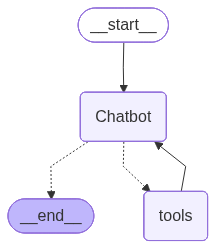

In [13]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable":{"thread_id": "1"}}

In [15]:
events = graph.stream(
    {'messages': user_input},
    config,
    stream_mode="values"
)

In [16]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_WlVsah516Hf6r1nXCcPmUMQr)
 Call ID: call_WlVsah516Hf6r1nXCcPmUMQr
  Args:
    query: Expert guidance for building an AI agent
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_WlVsah516Hf6r1nXCcPmUMQr)
 Call ID: call_WlVsah516Hf6r1nXCcPmUMQr
  Args:
    query: Expert guidance for building an AI agent


In [18]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    "It's much more reliable and extensible than simple autonomous agents"
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

The experts recommend using LangGraph to build your AI agent. LangGraph is a reliable and extensible platform for creating AI agents. It offers advanced capabilities for building sophisticated agents.
